In [ ]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [56]:
from sklearn.datasets import make_blobs
X_blob, y_blob = make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.5, random_state=7)
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)
X_blob.shape , y_blob.shape

(torch.Size([1000, 2]), torch.Size([1000]))

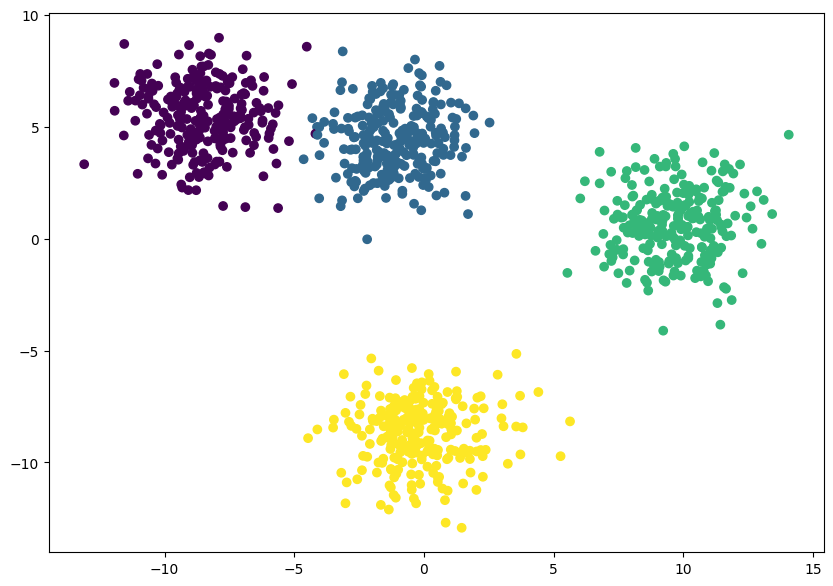

In [57]:
plt.figure(figsize=(10,7))
plt.scatter(x=X_blob[:,0], y=X_blob[:,1],c=y_blob)

In [58]:
X_train, X_test, y_train, y_test= train_test_split(X_blob, y_blob, test_size=0.2, random_state=7)
X_train.shape , X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [59]:
device="cuda" if torch.cuda.is_available() else "cpu"
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1=nn.Linear(in_features=2, out_features=8)
        self.linear_2=nn.Linear(in_features=8, out_features=8)
        self.linear_3=nn.Linear(in_features=8, out_features=4)

    def forward(self, X):
        return self.linear_3(self.linear_2(self.linear_1(X)))
classifier=Model().to(device)
classifier        

Model(
  (linear_1): Linear(in_features=2, out_features=8, bias=True)
  (linear_2): Linear(in_features=8, out_features=8, bias=True)
  (linear_3): Linear(in_features=8, out_features=4, bias=True)
)

In [60]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=classifier.parameters(), lr=0.1)
from torchmetrics import Accuracy
acc=Accuracy(task="multiclass", num_classes=4).to(device)

In [63]:
torch.manual_seed(7)
epochs=100

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    classifier.train()
    logits=classifier(X_train)
    preds=torch.argmax(torch.softmax(logits,dim=1), dim=1)
    loss=loss_func(logits,y_train)
    ac=acc(preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    classifier.eval()
    with torch.inference_mode():
        test_logits=classifier(X_test)
        test_preds=torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
        test_loss=loss_func(test_logits, y_test)
        test_ac=acc(test_preds, y_test)

        if epoch%10==0:
            print(f"Epoch: {epoch} | Train acc: {ac} | Train loss: {loss} | Test acc: {test_ac} | Test loss: {test_loss}")


Epoch: 0 | Train acc: 0.9850000143051147 | Train loss: 0.04951407015323639 | Test acc: 0.9850000143051147 | Test loss: 0.06026902049779892
Epoch: 10 | Train acc: 0.9862499833106995 | Train loss: 0.047255855053663254 | Test acc: 0.9850000143051147 | Test loss: 0.05909739062190056
Epoch: 20 | Train acc: 0.9862499833106995 | Train loss: 0.04523181542754173 | Test acc: 0.9900000095367432 | Test loss: 0.057982102036476135
Epoch: 30 | Train acc: 0.987500011920929 | Train loss: 0.04339064285159111 | Test acc: 0.9900000095367432 | Test loss: 0.05690433830022812
Epoch: 40 | Train acc: 0.9887499809265137 | Train loss: 0.04169634357094765 | Test acc: 0.9900000095367432 | Test loss: 0.05585264787077904
Epoch: 50 | Train acc: 0.9887499809265137 | Train loss: 0.04012298583984375 | Test acc: 0.9900000095367432 | Test loss: 0.05482012778520584
Epoch: 60 | Train acc: 0.9887499809265137 | Train loss: 0.03865145519375801 | Test acc: 0.9900000095367432 | Test loss: 0.053802553564310074
Epoch: 70 | Train a